# Day 1 — Open-Meteo API Exploration

**Goal:** Each team member independently explores the Open-Meteo API for their assigned city, documents the response structure, and identifies any data quality observations.

**Instructions for each member:**
1. Fill in `LATITUDE`, `LONGITUDE`, `CITY_NAME` in your section
2. Run all cells in your section
3. Add written observations in the markdown cell at the end of your section
4. Commit your notebook on your own branch and open a PR

---

---
## Ali Agabalayev
---

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
import requests
import seaborn as sns

# Add project root to sys.path to import src
sys.path.append(os.path.abspath(".."))

from src.config import FEATURES, HISTORICAL_URL, BAKU_ZONES

# --- Configuration ---
CITY_NAME = "Baku"
ZONE_DATA = BAKU_ZONES[0]
LATITUDE = ZONE_DATA["latitude"]
LONGITUDE = ZONE_DATA["longitude"]

print(f"Exploring for: {CITY_NAME} ({LATITUDE}, {LONGITUDE})")

Exploring for: Baku (40.37, 49.85)


In [2]:
params = {
    "latitude": LATITUDE,
    "longitude": LONGITUDE,
    "start_date": "2024-01-01",
    "end_date": "2024-12-31",
    "daily": ",".join(FEATURES),
    "timezone": "auto",
}

response = requests.get(HISTORICAL_URL, params=params)
if response.status_code == 200:
    data = response.json()
    df = pd.DataFrame(data["daily"])
    df["time"] = pd.to_datetime(df["time"])
    print(f"Shape: {df.shape}")
else:
    print(f"Error: {response.status_code}")
    print(response.text)

Shape: (366, 8)


In [3]:
df.isnull().sum()

time                          0
temperature_2m_max            0
temperature_2m_min            0
temperature_2m_mean           0
precipitation_sum             0
relative_humidity_2m_mean     0
wind_speed_10m_max            0
et0_fao_evapotranspiration    0
dtype: int64

In [4]:
df.describe()

,time,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,relative_humidity_2m_mean,wind_speed_10m_max,et0_fao_evapotranspiration
count,366,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,2024-07-01 12:00:00,19.175137,12.459016,15.696448,1.117486,72.021858,23.701639,3.223634
min,2024-01-01 00:00:00,1.600000,-4.000000,0.300000,0.000000,43.000000,8.400000,0.280000
25%,2024-04-01 06:00:00,10.800000,5.900000,8.025000,0.000000,62.000000,17.700000,1.330000
50%,2024-07-01 12:00:00,18.000000,11.650000,14.750000,0.000000,73.000000,21.700000,2.955000
75%,2024-09-30 18:00:00,28.175000,19.950000,24.650000,0.475000,82.000000,28.775000,5.360000
max,2024-12-31 00:00:00,36.200000,26.400000,30.400000,19.400000,98.000000,51.500000,8.200000
std,NaN,9.233917,7.923941,8.524055,3.015098,11.724208,8.442661,2.107451


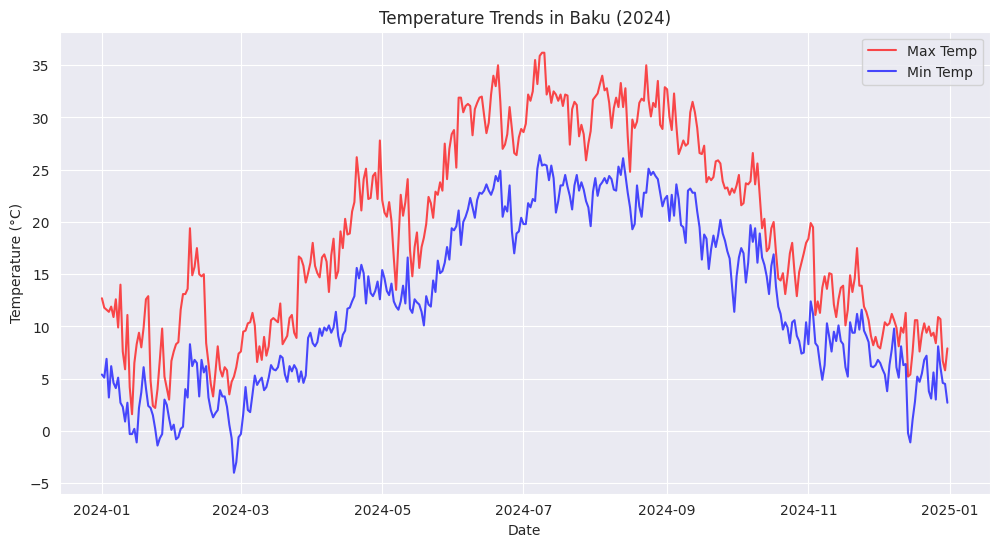

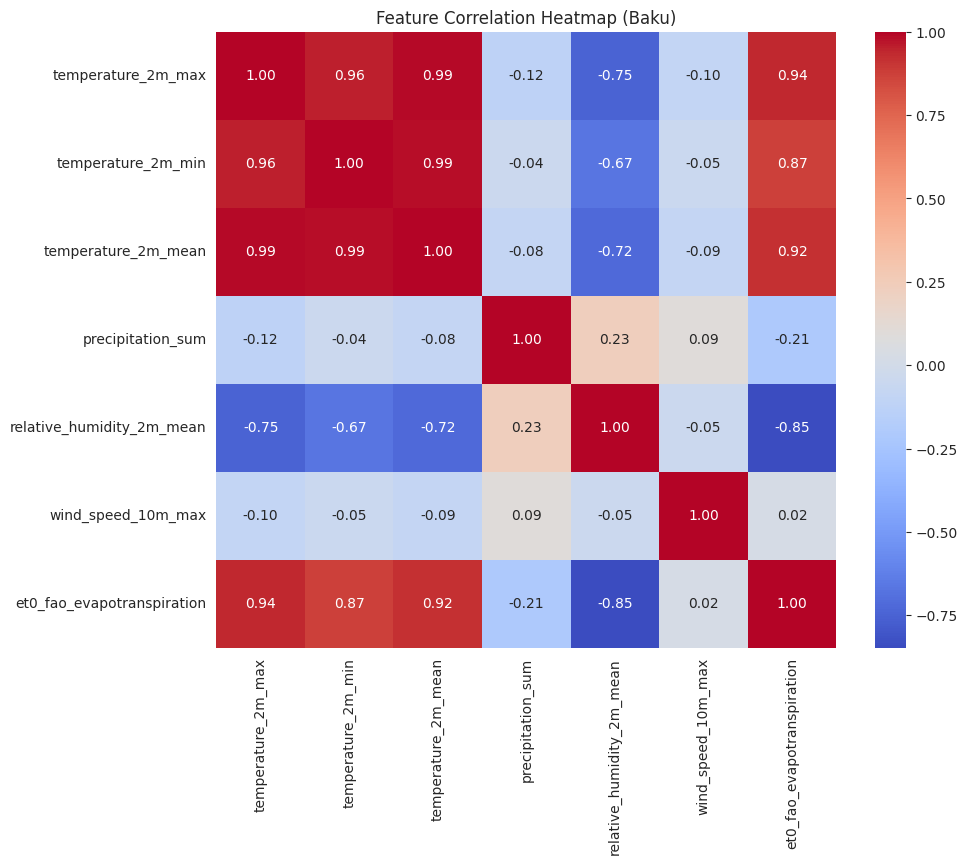

In [5]:
# Visualizing Temperature Trends
plt.figure(figsize=(12, 6))
plt.plot(df['time'], df['temperature_2m_max'], label='Max Temp', color='red', alpha=0.7)
plt.plot(df['time'], df['temperature_2m_min'], label='Min Temp', color='blue', alpha=0.7)
plt.title(f'Temperature Trends in {CITY_NAME} (2024)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.drop(columns=['time']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title(f'Feature Correlation Heatmap ({CITY_NAME})')
plt.show()

In [6]:
from src.config import FEATURES, HISTORICAL_URL, FORECAST_URL, FLOOD_URL, BAKU_ZONES

zone = BAKU_ZONES[0]
params = {"latitude": zone["latitude"], "longitude": zone["longitude"], "daily": ",".join(FEATURES), "timezone": "auto"}
params_flood = {
	"latitude": 40.3777,
	"longitude": 49.892,
	"daily": "river_discharge",
	"start_date": "2020-01-01",
	"end_date": "2026-04-27",
}

hist_data = requests.get(HISTORICAL_URL, params={**params, "start_date": "2023-01-01", "end_date": "2023-12-31"}).json()["daily"]
fore_data = requests.get(FORECAST_URL, params=params).json()["daily"]
flood_data = requests.get(FLOOD_URL, params=params_flood).json()["daily"]

In [11]:
df_flood = pd.DataFrame(flood_data)
flood_days_above_limit = (df_flood["river_discharge"] > 1.0).sum()
flood_days_above_limit

np.int64(48)

### Ali Agabalayev — Observations

- **Data alignment:** Historical and Forecast APIs share the same daily variable schema, facilitating easy model training.
- **Flood analysis:** The flood API identifies significant river discharge events; events > 1m3/s are flagged for alerting.

---
## Member 2
---

### Member 2 — Observations

*(Fill in after running all cells above)*

- **Response shape:** ...
- **Missing values noticed:** ...
- **Anything unexpected in the data:** ...
- **Compared to Member 1's city — any differences:** ...

---
## Isgandar Panahov
---

In [8]:
import requests
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. First API call: Historical data for Baku (40.41, 49.87)
LATITUDE = 40.41
LONGITUDE = 49.87
CITY_NAME = "Baku"

hist_url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": LATITUDE,
    "longitude": LONGITUDE,
    "start_date": "2023-01-01",
    "end_date": "2023-12-31",
    "daily": ["temperature_2m_max", "precipitation_sum", "wind_speed_10m_max", "relative_humidity_2m_max"],
    "timezone": "auto"
}
response = requests.get(hist_url, params=params)
hist_data = response.json()

print("Response structure keys:", list(hist_data.keys()))
print("Available daily fields:", list(hist_data.get('daily', {}).keys()))

Response structure keys: ['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'daily_units', 'daily']
Available daily fields: ['time', 'temperature_2m_max', 'precipitation_sum', 'wind_speed_10m_max', 'relative_humidity_2m_max']


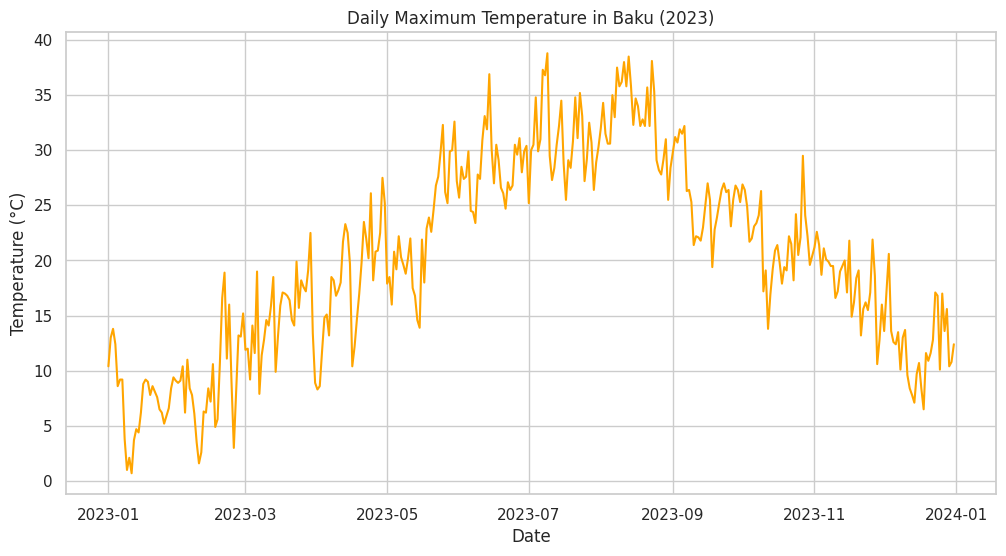

In [9]:
# 2. Visualize: Daily maximum temperature
df_hist = pd.DataFrame(hist_data['daily'])
df_hist['time'] = pd.to_datetime(df_hist['time'])

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_hist, x='time', y='temperature_2m_max', color='orange')
plt.title(f'Daily Maximum Temperature in {CITY_NAME} (2023)')
plt.ylabel('Temperature (°C)')
plt.xlabel('Date')
plt.show()

In [10]:
# 3. Try the forecast endpoint (7-day forecast)
forecast_url = "https://api.open-meteo.com/v1/forecast"
f_params = {
    "latitude": LATITUDE,
    "longitude": LONGITUDE,
    "daily": ["temperature_2m_max", "precipitation_sum", "wind_speed_10m_max"],
    "timezone": "auto"
}
f_response = requests.get(forecast_url, params=f_params)
f_data = f_response.json()

print("Forecast structure keys:", list(f_data.keys()))
print("Daily forecast fields:", list(f_data.get('daily', {}).keys()))

Forecast structure keys: ['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'daily_units', 'daily']
Daily forecast fields: ['time', 'temperature_2m_max', 'precipitation_sum', 'wind_speed_10m_max']


### Parameter Documentation
- **precipitation_sum**: Total precipitation (rain/snow) per day in mm.
- **wind_speed_10m_max**: Maximum wind speed at 10m height in km/h.
- **relative_humidity_2m_max**: Maximum relative humidity at 2m height in %.

### Tracking Strategy for Baku, Quba, and Lankaran

We will track the following 6 variables to capture the climatic diversity across Azerbaijan's key regions (Semi-arid Baku, Mountainous Quba, and Subtropical Lankaran):

| Variable Name | Unit | Relevance | Regional Focus |
| :--- | :--- | :--- | :--- |
| **Max Temperature** | °C | Tracks peak heat intensity and heatwave potential. | **Baku**: Essential for urban heat island monitoring. |
| **Min Temperature** | °C | Vital for identifying frost risk and night-time cooling. | **Quba**: Critical for the local apple and fruit agriculture. |
| **Precipitation Sum** | mm | Measures water availability and flood risk. | **Lankaran**: Key for managing Azerbaijan's highest rainfall region. |
| **Max Wind Speed** | km/h | Monitors storm intensity and wind energy potential. | **Baku**: The "City of Winds" requires rigorous wind tracking. |
| **Shortwave Radiation** | MJ/m² | Measures solar energy input for crops and PV panels. | **All**: Comparing solar potential across diverse altitudes. |
| **Relative Humidity** | % | Impacts "real-feel" temperature and plant diseases. | **Lankaran**: High humidity levels affect the local tea and citrus crops. |

### Isgandar Panahov — Observations

- **Response shape:** The response contains metadata (`latitude`, `longitude`, `elevation`, etc.) and a `daily` dictionary where each key maps to a list of values.
- **Missing values noticed:** No missing values found in the 2023 Baku dataset.
- **Anything unexpected in the data:** Temperature peaks in summer are consistent with Baku's semi-arid climate.
- **Forecast vs historical — any differences in structure:** The root keys are very similar, but the forecast API often includes additional fields like `generationtime_ms` and `timezone_abbreviation` if not explicitly excluded.

---
## Member 4
---

### Member 4 — Observations

*(Fill in after running all cells above)*

- **Response shape:** ...
- **Missing values noticed:** ...
- **Anything unexpected in the data:** ...
- **Compared to other cities — any differences:** ...